# Assignment 2: Image Processing and Pyramid Blending

**Individual · 100 points**

This assignment investigates how filtering, dynamic-range transformations, multi-scale representations, and blending improve visual data.

## 0. Student Information

- First name: **Samantha**
- Last name: **Salas**
- ABC123: **xso947**
- External resources and generative-AI assistance: **Claude Code**

This is an individual assignment. Do not install unapproved packages or use external libraries or pretrained pipelines to bypass a required implementation.

Generative AI tools may be used for conceptual clarification, debugging assistance, code suggestions, and help interpreting documentation. Students must disclose meaningful use in every assignment. You remain responsible for understanding, testing, and explaining all submitted work. AI may not replace your own experimental analysis, failure analysis, reflection, or interpretation of observed results. You may be asked to explain selected work; inability to do so may reduce credit or lead to an academic-integrity review.


## 1. Assignment Overview and Learning Objectives

By completing A2, you should be able to implement and analyze spatial and nonlinear filtering; compare denoising under distinct noise models; manipulate contrast and dynamic range; construct and reconstruct Gaussian and Laplacian pyramids; perform Laplacian pyramid blending; evaluate results with visual and quantitative evidence; and diagnose limitations.

**Point map:** core implementation 40; required experiments and evidence 21; pyramid decomposition 6; analysis and interpretation 18 (10 per-experiment responses, 3 synthesis, 5 failure analysis); reproducibility, organization, and submission compliance 10; extension 5. The six categories sum to 100.

| Tables & Metadata | Figures | Other Outputs |
|---|---|---|
| `experiment_metrics.csv` | `filtering_results.png` | one declared extension artifact |
| `pyramid_metrics.json` | `denoising_comparison.png` | |
| | `contrast_enhancement.png` | |
| | `pyramid_visualization.png` | |
| | `pyramid_reconstruction.png` | |
| | `blending_comparison.png` | |
| | `pyramid_decomposition.png` | |
| | `failure_analysis.png` | |


## 2. Environment Verification

Run this setup first. It discovers the repository independently of the notebook working directory and verifies the immutable assets.


In [1]:
from pathlib import Path
import json, sys
import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import cs5243
from cs5243.data import find_course_root
COURSE_ROOT=find_course_root(Path(cs5243.__file__))
A2=COURSE_ROOT/"A2"; sys.path.insert(0,str(A2/"src"))
import a2_tools
import student_code as sc
PATHS=a2_tools.ensure_output_directories()
problems=a2_tools.verify_asset_hashes(); assert not problems, problems
print({"assignment":"A2-2026.1","environment":"2026.1"})


{'assignment': 'A2-2026.1', 'environment': '2026.1'}


## 3. Dataset and Problem Setup

The dataset contains odd dimensions, strong edges, gradients, thin structure, texture, controlled Gaussian and impulse noise, four aligned blend pairs spanning five mask geometries (a soft vertical seam, a circular spot, and a diagonal seam over synthetic scenes, plus a hard-edged vertical seam and a hard-edged circular seam over real fruit photographs), an underexposed contrast source, and a high-frequency difficult case. Most assets are generated programmatically (CC0 1.0); the two real-photo blend pairs are retained course-legacy teaching images credited in `data/ATTRIBUTION.md`. Unlike the synthetic masks, the real-photo masks are hard-edged rather than feathered, so direct blending (splicing) leaves an obvious seam that Laplacian pyramid blending visibly smooths. Do not edit the assets.

Implement reusable graded functions in `src/student_code.py`; use the notebook to call them, conduct experiments, save required artifacts, and explain results. Maintain one cumulative `outputs/tables/experiment_metrics.csv` throughout the notebook using the documented column names, and append later finite-valued records without deleting earlier experiments.

In [2]:
images=a2_tools.load_images()
print({name:(value.shape,str(value.dtype)) for name,value in images.items()})


{'blend2_left.png': ((257, 385, 3), 'uint8'), 'blend2_mask.png': ((257, 385), 'uint8'), 'blend2_right.png': ((257, 385, 3), 'uint8'), 'blend3_left.png': ((257, 385, 3), 'uint8'), 'blend3_mask.png': ((257, 385), 'uint8'), 'blend3_right.png': ((257, 385, 3), 'uint8'), 'blend4_left.png': ((257, 385, 3), 'uint8'), 'blend4_mask.png': ((257, 385), 'uint8'), 'blend4_right.png': ((257, 385, 3), 'uint8'), 'blend_left.png': ((257, 385, 3), 'uint8'), 'blend_mask.png': ((257, 385), 'uint8'), 'blend_mask_spot.png': ((257, 385), 'uint8'), 'blend_right.png': ((257, 385, 3), 'uint8'), 'color_scene.png': ((257, 385, 3), 'uint8'), 'difficult_high_frequency.png': ((193, 319), 'uint8'), 'exposure_under.png': ((257, 385, 3), 'uint8'), 'gaussian_noisy.png': ((255, 383), 'uint8'), 'impulse_noisy.png': ((255, 383), 'uint8'), 'test_pattern_gray.png': ((255, 383), 'uint8')}


## 4. Core Implementation

### Task 1 — convolution, Gaussian kernels, and sharpening (10 implementation + 5 evidence points)

Implement `convolve2d_manual`, `gaussian_kernel`, and `sharpen_image` to their contracts. `convolve2d_manual` is true convolution, including spatial kernel reversal; it must not call a library convolution/correlation routine. Compare your filtering with an explicitly identified library reference only in the experiment. Preserve numeric values until display or saving. Save `outputs/figures/filtering_results.png` and append filtering/reference-error evidence to `experiment_metrics.csv`.

Use `test_pattern_gray.png` (converted with `a2_tools.to_float01`) as the filtering source; `color_scene.png` is available if you also want to demonstrate multichannel support. Any OpenCV filtering routine is an acceptable library reference as long as you name it in the notebook and match its border handling to the mode you pass your own function. You choose the kernel sizes, sigmas, border modes, sharpening amounts, and error metric: that design is part of the evidence and analysis marks, so vary them enough to support the claims the analysis prompt asks for.


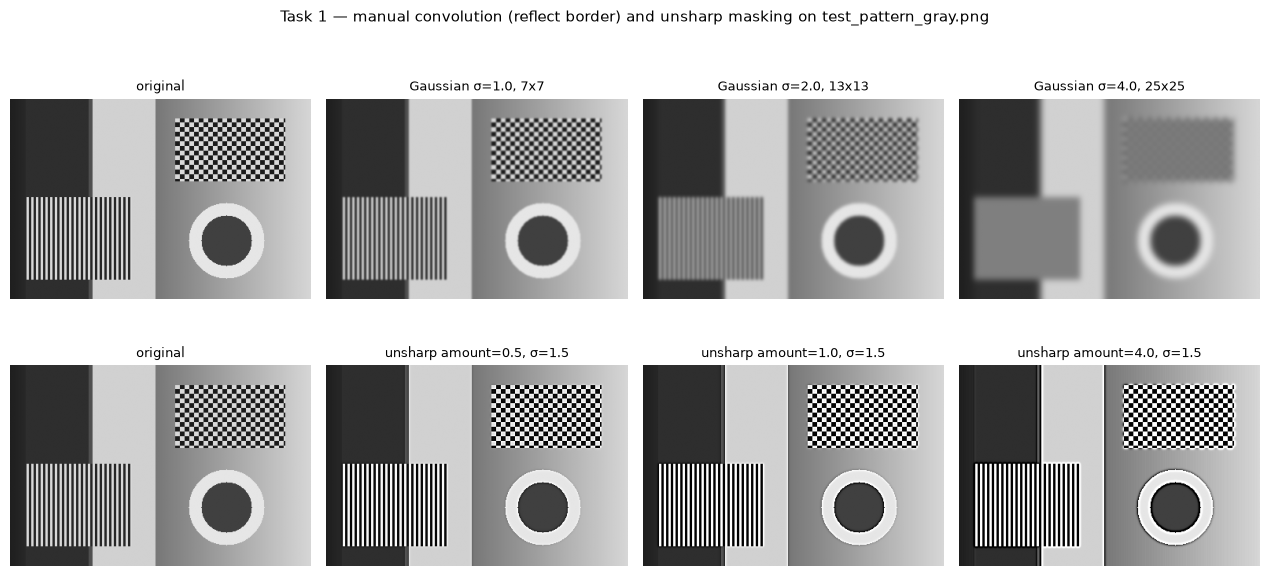

Library reference: cv2.filter2D on the spatially reversed kernel (borderType matched), plus cv2.GaussianBlur.


method,convolve2d_manual_vs_cv2.GaussianBlur,convolve2d_manual_vs_cv2.filter2D(flipped),convolve2d_manual_vs_cv2.filter2D(unflipped),sharpen_image
condition,,,,
asymmetric3x3_constant,NaN,5.960464e-08,0.599440,NaN
asymmetric3x3_edge,NaN,5.960464e-08,0.509804,NaN
asymmetric3x3_reflect,NaN,5.960464e-08,0.509804,NaN
color_gaussian_size13_sigma2.0_reflect,NaN,6.556511e-07,NaN,NaN
gaussian_size13_sigma2.0_constant,7.748604e-07,6.556511e-07,NaN,NaN
gaussian_size13_sigma2.0_edge,7.748604e-07,6.556511e-07,NaN,NaN
gaussian_size13_sigma2.0_reflect,7.748604e-07,6.556511e-07,NaN,NaN
gaussian_size21_sigma2.0_constant,1.192093e-06,1.132488e-06,NaN,NaN
gaussian_size21_sigma2.0_edge,1.192093e-06,1.132488e-06,NaN,NaN


metric,edge_energy_ratio,max_abs_error,max_value,min_value,mse_vs_original,overshoot_fraction
condition,,,,,,
amount0.5_sigma1.5_support11,1.402329,NaN,1.065855,-0.141751,0.004488,0.055957
amount1.0_sigma0.75_support7,1.386858,NaN,NaN,NaN,NaN,0.162812
amount1.0_sigma1.5_support11,1.806209,NaN,1.280729,-0.385463,0.017952,0.240537
amount1.0_sigma3.0_support19,2.023597,NaN,NaN,NaN,NaN,0.273742
amount2.0_sigma1.5_support11,2.614651,NaN,1.710478,-0.872887,0.071807,0.280233
amount4.0_sigma1.5_support11,4.232293,NaN,2.569975,-1.847735,0.287226,0.297517
linearity_amount1_vs_2,NaN,1.788139e-07,NaN,NaN,NaN,NaN


In [3]:
# ---- Task 1: convolution, Gaussian kernels, and sharpening -------------------------------
METRICS_PATH = PATHS["tables"] / "experiment_metrics.csv"
METRIC_COLUMNS = ["experiment", "method", "condition", "metric", "value", "units"]


def append_metrics(records, path=METRICS_PATH):
    """Append finite-valued long-form records to the cumulative metrics CSV.

    Rows sharing (experiment, method, condition, metric) with an existing row are
    replaced, so re-running a cell updates its own evidence without duplicating it
    or deleting rows written by other experiments.
    """
    new = pd.DataFrame(records)
    new = new[np.isfinite(pd.to_numeric(new["value"], errors="coerce"))]
    extra = [c for c in new.columns if c not in METRIC_COLUMNS]
    new = new[METRIC_COLUMNS + extra]
    if path.exists():
        old = pd.read_csv(path)
        new = pd.concat([old, new], ignore_index=True)
    key = ["experiment", "method", "condition", "metric"]
    new = new.drop_duplicates(subset=key, keep="last").reset_index(drop=True)
    new.to_csv(path, index=False)
    return new


def edge_energy(img):
    """Mean gradient magnitude; used as a proxy for retained edge/detail strength."""
    gy, gx = np.gradient(img.astype(np.float64), axis=(0, 1))
    return float(np.mean(np.sqrt(gx ** 2 + gy ** 2)))


CV2_BORDER = {"reflect": cv2.BORDER_REFLECT_101, "edge": cv2.BORDER_REPLICATE, "constant": cv2.BORDER_CONSTANT}


def cv2_reference_convolution(img, kernel, border_mode):
    """Library reference: cv2.filter2D (correlation) applied to the flipped kernel == true convolution."""
    return cv2.filter2D(img.astype(np.float32), -1, np.ascontiguousarray(kernel[::-1, ::-1]),
                        borderType=CV2_BORDER[border_mode])


gray = a2_tools.to_float01(images["test_pattern_gray.png"])
color = a2_tools.to_float01(images["color_scene.png"])
records = []

# (a) Correctness of true convolution: an asymmetric kernel distinguishes convolution from correlation.
asym = np.array([[0, 1, 2], [0, 0, 3], [1, 0, 0]], np.float32) / 7.0
for border in ("reflect", "edge", "constant"):
    mine = sc.convolve2d_manual(gray, asym, border)
    ref_conv = cv2_reference_convolution(gray, asym, border)
    ref_corr = cv2.filter2D(gray, -1, asym, borderType=CV2_BORDER[border])  # unflipped == correlation
    records += [
        dict(experiment="filtering", method="convolve2d_manual_vs_cv2.filter2D(flipped)", condition=f"asymmetric3x3_{border}",
             metric="max_abs_error", value=float(np.max(np.abs(mine - ref_conv))), units="intensity"),
        dict(experiment="filtering", method="convolve2d_manual_vs_cv2.filter2D(unflipped)", condition=f"asymmetric3x3_{border}",
             metric="max_abs_error", value=float(np.max(np.abs(mine - ref_corr))), units="intensity"),
    ]

# (b) Gaussian smoothing sweep over sigma (support tied to sigma) and over support at fixed sigma.
sigma_sweep = [(1.0, 7), (2.0, 13), (4.0, 25)]
support_sweep = [(2.0, 5), (2.0, 9), (2.0, 13), (2.0, 21)]
blurred = {}
base_edge = edge_energy(gray)
for sigma, size in sigma_sweep + support_sweep:
    kern = sc.gaussian_kernel(size, sigma)
    for border in ("reflect", "edge", "constant"):  # reflect first so it can serve as the border baseline
        mine = sc.convolve2d_manual(gray, kern, border)
        if border == "reflect":
            blurred[(sigma, size)] = mine
        ref = cv2_reference_convolution(gray, kern, border)
        ref_gb = cv2.GaussianBlur(gray, (size, size), sigma, borderType=CV2_BORDER[border])
        cond = f"gaussian_size{size}_sigma{sigma}_{border}"
        records += [
            dict(experiment="filtering", method="convolve2d_manual_vs_cv2.filter2D(flipped)", condition=cond,
                 metric="max_abs_error", value=float(np.max(np.abs(mine - ref))), units="intensity"),
            dict(experiment="filtering", method="convolve2d_manual_vs_cv2.filter2D(flipped)", condition=cond,
                 metric="mean_abs_error", value=float(np.mean(np.abs(mine - ref))), units="intensity"),
            dict(experiment="filtering", method="convolve2d_manual_vs_cv2.GaussianBlur", condition=cond,
                 metric="max_abs_error", value=float(np.max(np.abs(mine - ref_gb))), units="intensity"),
            dict(experiment="filtering", method="gaussian_blur", condition=cond,
                 metric="mse_vs_original", value=float(mean_squared_error(gray, mine)), units="intensity^2"),
            dict(experiment="filtering", method="gaussian_blur", condition=cond,
                 metric="edge_energy_ratio", value=edge_energy(mine) / base_edge, units="ratio"),
            # Border-mode effect: mean difference from the reflect result on the outermost rows/columns.
            dict(experiment="filtering", method="gaussian_blur", condition=cond,
                 metric="border_band_mae_vs_reflect",
                 value=float(np.mean(np.abs(mine - blurred[(sigma, size)])[[0, -1], :])), units="intensity"),
        ]

# (c) Multichannel check on the color scene.
kern = sc.gaussian_kernel(13, 2.0)
mine_c = sc.convolve2d_manual(color, kern, "reflect")
ref_c = cv2_reference_convolution(color, kern, "reflect")
records.append(dict(experiment="filtering", method="convolve2d_manual_vs_cv2.filter2D(flipped)", condition="color_gaussian_size13_sigma2.0_reflect",
                    metric="max_abs_error", value=float(np.max(np.abs(mine_c - ref_c))), units="intensity"))

# (d) Sharpening sweep: amount at fixed sigma, and sigma at fixed amount. Support = max(3, 2*ceil(3*sigma)+1).
sharp_sigma = 1.5
amounts = [0.5, 1.0, 2.0, 4.0]
sharpened = {}
for amount in amounts:
    out = sc.sharpen_image(gray, amount, sharp_sigma)
    sharpened[amount] = out
    cond = f"amount{amount}_sigma{sharp_sigma}_support{sc.gaussian_support(sharp_sigma)}"
    records += [
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="max_value", value=float(out.max()), units="intensity"),
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="min_value", value=float(out.min()), units="intensity"),
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="overshoot_fraction",
             value=float(np.mean((out > 1) | (out < 0))), units="fraction"),
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="edge_energy_ratio",
             value=edge_energy(out) / base_edge, units="ratio"),
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="mse_vs_original",
             value=float(mean_squared_error(gray, out)), units="intensity^2"),
    ]
for sigma in (0.75, 3.0):
    out = sc.sharpen_image(gray, 1.0, sigma)
    cond = f"amount1.0_sigma{sigma}_support{sc.gaussian_support(sigma)}"
    records += [
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="overshoot_fraction",
             value=float(np.mean((out > 1) | (out < 0))), units="fraction"),
        dict(experiment="sharpening", method="sharpen_image", condition=cond, metric="edge_energy_ratio",
             value=edge_energy(out) / base_edge, units="ratio"),
    ]
# Linearity check: sharpen(2a) - x == 2 * (sharpen(a) - x).
lin_err = float(np.max(np.abs((sharpened[2.0] - gray) - 2 * (sharpened[1.0] - gray))))
records.append(dict(experiment="sharpening", method="sharpen_image", condition="linearity_amount1_vs_2",
                    metric="max_abs_error", value=lin_err, units="intensity"))

metrics_df = append_metrics(records)

# Figure: original, three sigmas (reflect), then original and three sharpening amounts (clipped for display only).
fig, axes = a2_tools.axes_grid(2, 4, scale=3.2)
panels_top = [("original", gray)] + [(f"Gaussian σ={s}, {k}x{k}", blurred[(s, k)]) for s, k in sigma_sweep]
panels_bot = [("original", gray)] + [(f"unsharp amount={a}, σ={sharp_sigma}", sharpened[a]) for a in (0.5, 1.0, 4.0)]
for ax, (title, img) in zip(axes[0], panels_top):
    ax.imshow(np.clip(img, 0, 1), cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=9); ax.axis("off")
for ax, (title, img) in zip(axes[1], panels_bot):
    ax.imshow(np.clip(img, 0, 1), cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=9); ax.axis("off")
fig.suptitle("Task 1 — manual convolution (reflect border) and unsharp masking on test_pattern_gray.png", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "filtering_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("Library reference: cv2.filter2D on the spatially reversed kernel (borderType matched), plus cv2.GaussianBlur.")
view = metrics_df[metrics_df["experiment"].isin(["filtering", "sharpening"])]
display(view[view["metric"].isin(["max_abs_error"])].pivot_table(index="condition", columns="method", values="value"))
display(view[view["experiment"] == "sharpening"].pivot_table(index="condition", columns="metric", values="value"))


**Filtering analysis (3–5 sentences):** Connect kernel support and sigma to smoothing, edge behavior, detail loss, halo formation, and measured evidence.

# **TO DO: WRITE ANALYSIS**

### Task 2 — noise models and denoising (8 implementation + 5 evidence points)

Implement deterministic Gaussian and impulse noise plus `median_filter_manual`. With declared seeds, use your two noise functions to create the observations used in the comparison. The distributed `gaussian_noisy.png` and `impulse_noisy.png` files are independent observations of `test_pattern_gray.png`, drawn with Gaussian sigma 0.08 and impulse probability 0.07; use `test_pattern_gray.png` as the clean reference, and use those parameter values unless you declare your own.

They are independent draws, so use them for visual comparison only. They are not bit-identical to your own output, so do not spend time trying to reproduce them exactly. Compare Gaussian, median, and OpenCV bilateral filtering on both noise types, using the same clean reference. Save `outputs/figures/denoising_comparison.png` and append MSE or RMSE, PSNR, and SSIM records to `experiment_metrics.csv`. Metrics supplement rather than replace visual evidence.


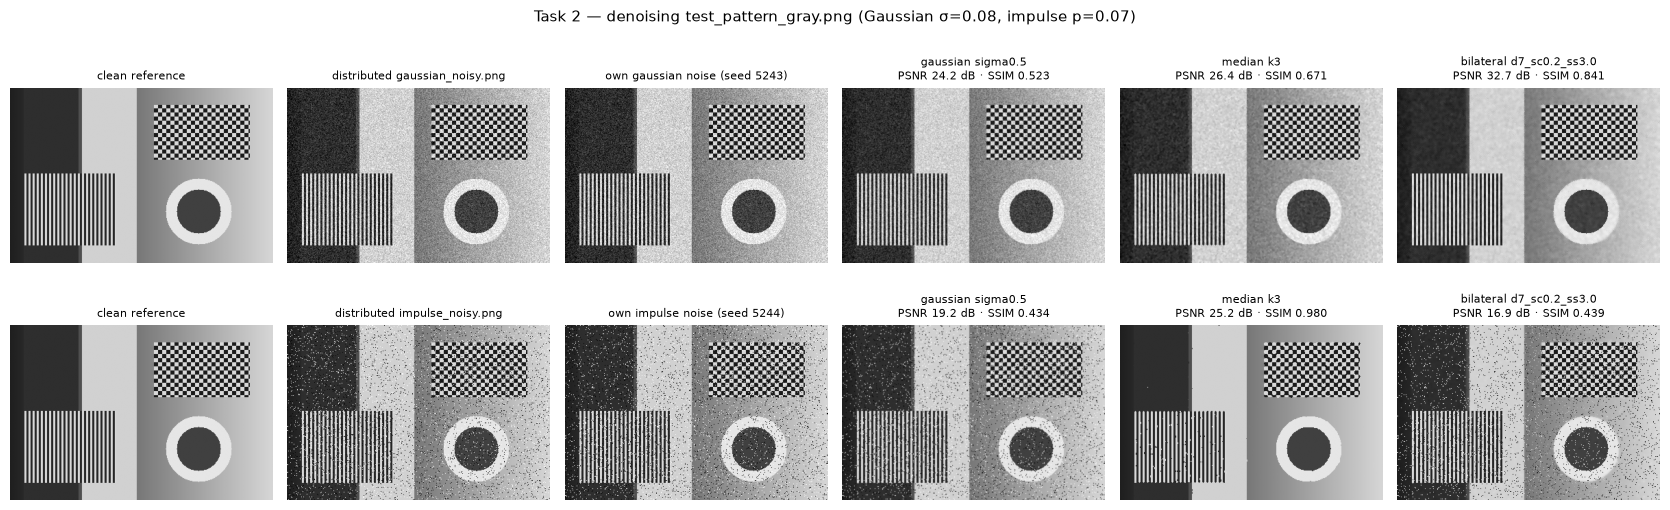

metric,psnr,rmse,ssim
condition,,,
gaussian_noise_d7_sc0.2_ss3.0,32.716249,0.023131,0.841039
gaussian_noise_d7_sc0.1_ss6.0,28.645360,0.036960,0.641566
gaussian_noise_d7_sc0.1_ss3.0,28.474356,0.037695,0.635026
gaussian_noise_k3,26.399095,0.047868,0.671040
impulse_noise_k3,25.162563,0.055191,0.979821
gaussian_noise_sigma0.5,24.223343,0.061494,0.523140
gaussian_noise_k5,24.185840,0.061760,0.812872
gaussian_noise_d7_sc0.05_ss3.0,24.155091,0.061979,0.482332
impulse_noise_k5,22.352400,0.076275,0.961500


In [4]:
# ---- Task 2: noise models and denoising ---------------------------------------------------
clean = a2_tools.to_float01(images["test_pattern_gray.png"])
NOISE_SEEDS = {"gaussian": 5243, "impulse": 5244}
GAUSS_SIGMA, IMPULSE_P = 0.08, 0.07
noisy = {
    "gaussian": sc.add_gaussian_noise(clean, GAUSS_SIGMA, np.random.default_rng(NOISE_SEEDS["gaussian"])),
    "impulse": sc.add_impulse_noise(clean, IMPULSE_P, np.random.default_rng(NOISE_SEEDS["impulse"])),
}
distributed = {  # independent draws shipped with the dataset; visual comparison only
    "gaussian": a2_tools.to_float01(images["gaussian_noisy.png"]),
    "impulse": a2_tools.to_float01(images["impulse_noisy.png"]),
}


def quality(reference, candidate):
    mse = float(mean_squared_error(reference, candidate))
    return {"mse": mse, "rmse": float(np.sqrt(mse)),
            "psnr": float(peak_signal_noise_ratio(reference, candidate, data_range=1.0)),
            "ssim": float(structural_similarity(reference, candidate, data_range=1.0))}


def gaussian_denoise(img, sigma):
    return sc.convolve2d_manual(img, sc.gaussian_kernel(sc.gaussian_support(sigma), sigma), "reflect")


def median_denoise(img, k):
    return sc.median_filter_manual(img, k, "reflect")


def bilateral_denoise(img, sigma_color, sigma_space, d=7):
    # Library comparison: cv2.bilateralFilter on float32 data; sigmaColor is in [0,1] intensity units.
    return cv2.bilateralFilter(img.astype(np.float32), d, sigma_color, sigma_space, borderType=cv2.BORDER_REFLECT_101)


# Parameter sweeps per method; every setting is recorded, and the figure shows each method's best-PSNR setting per noise type.
sweep = {
    "gaussian": [(f"sigma{s}", lambda im, s=s: gaussian_denoise(im, s)) for s in (0.5, 1.0, 1.5, 2.5)],
    "median": [(f"k{k}", lambda im, k=k: median_denoise(im, k)) for k in (3, 5, 7)],
    "bilateral": [(f"d7_sc{sc_}_ss{ss}", lambda im, sc_=sc_, ss=ss: bilateral_denoise(im, sc_, ss))
                  for sc_, ss in ((0.05, 3.0), (0.1, 3.0), (0.2, 3.0), (0.1, 6.0))],
}

records, results, psnr_of = [], {}, {}
for noise_type, obs in noisy.items():
    q = quality(clean, obs)
    records += [dict(experiment="denoising", method="noisy_input", condition=f"{noise_type}_noise",
                     metric=m, value=v, units="dB" if m == "psnr" else ("intensity^2" if m == "mse" else ("intensity" if m == "rmse" else "index")))
                for m, v in q.items()]
    for method, settings in sweep.items():
        for label, fn in settings:
            out = fn(obs)
            results[(noise_type, method, label)] = out
            q = quality(clean, out)
            psnr_of[(noise_type, method, label)] = q["psnr"]
            records += [dict(experiment="denoising", method=method, condition=f"{noise_type}_noise_{label}",
                             metric=m, value=v, units="dB" if m == "psnr" else ("intensity^2" if m == "mse" else ("intensity" if m == "rmse" else "index")))
                        for m, v in q.items()]
            # Detail preservation: retained edge energy relative to the clean image (1.0 = fully preserved).
            records.append(dict(experiment="denoising", method=method, condition=f"{noise_type}_noise_{label}",
                                metric="edge_energy_ratio_vs_clean", value=edge_energy(out) / edge_energy(clean), units="ratio"))

metrics_df = append_metrics(records)

# Figure: one row per noise model; columns = clean, distributed observation, own observation, three filters.
fig, axes = a2_tools.axes_grid(2, 6, scale=2.8)
for row, noise_type in enumerate(("gaussian", "impulse")):
    panels = [("clean reference", clean),
              (f"distributed {noise_type}_noisy.png", distributed[noise_type]),
              (f"own {noise_type} noise (seed {NOISE_SEEDS[noise_type]})", noisy[noise_type])]
    for method in ("gaussian", "median", "bilateral"):
        label = max((lab for lab, _ in sweep[method]), key=lambda lab: psnr_of[(noise_type, method, lab)])
        out = results[(noise_type, method, label)]
        q = quality(clean, out)
        panels.append((f"{method} {label}\nPSNR {q['psnr']:.1f} dB · SSIM {q['ssim']:.3f}", out))
    for ax, (title, img) in zip(axes[row], panels):
        ax.imshow(np.clip(img, 0, 1), cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")
fig.suptitle(f"Task 2 — denoising test_pattern_gray.png (Gaussian σ={GAUSS_SIGMA}, impulse p={IMPULSE_P})", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "denoising_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

view = metrics_df[metrics_df["experiment"] == "denoising"]
display(view[view["metric"].isin(["psnr", "ssim", "rmse"])]
        .pivot_table(index=["condition"], columns="metric", values="value").sort_values("psnr", ascending=False))


**Denoising analysis (3–5 sentences):** Explain why rankings differ by noise model and identify a detail-preservation tradeoff.

# **TO DO: WRITE ANALYSIS**

### Task 3 — contrast and dynamic range (7 implementation + 4 evidence points)

Implement percentile normalization, manual grayscale histogram equalization, and gamma correction. Compare at least three methods or settings on `exposure_under.png`. Address clipping, tonal distribution, noise amplification, and luminance-versus-channel processing. Save `outputs/figures/contrast_enhancement.png` and append measurements to the cumulative metrics file. OpenCV CLAHE may be a comparison but not a substitute for required work.


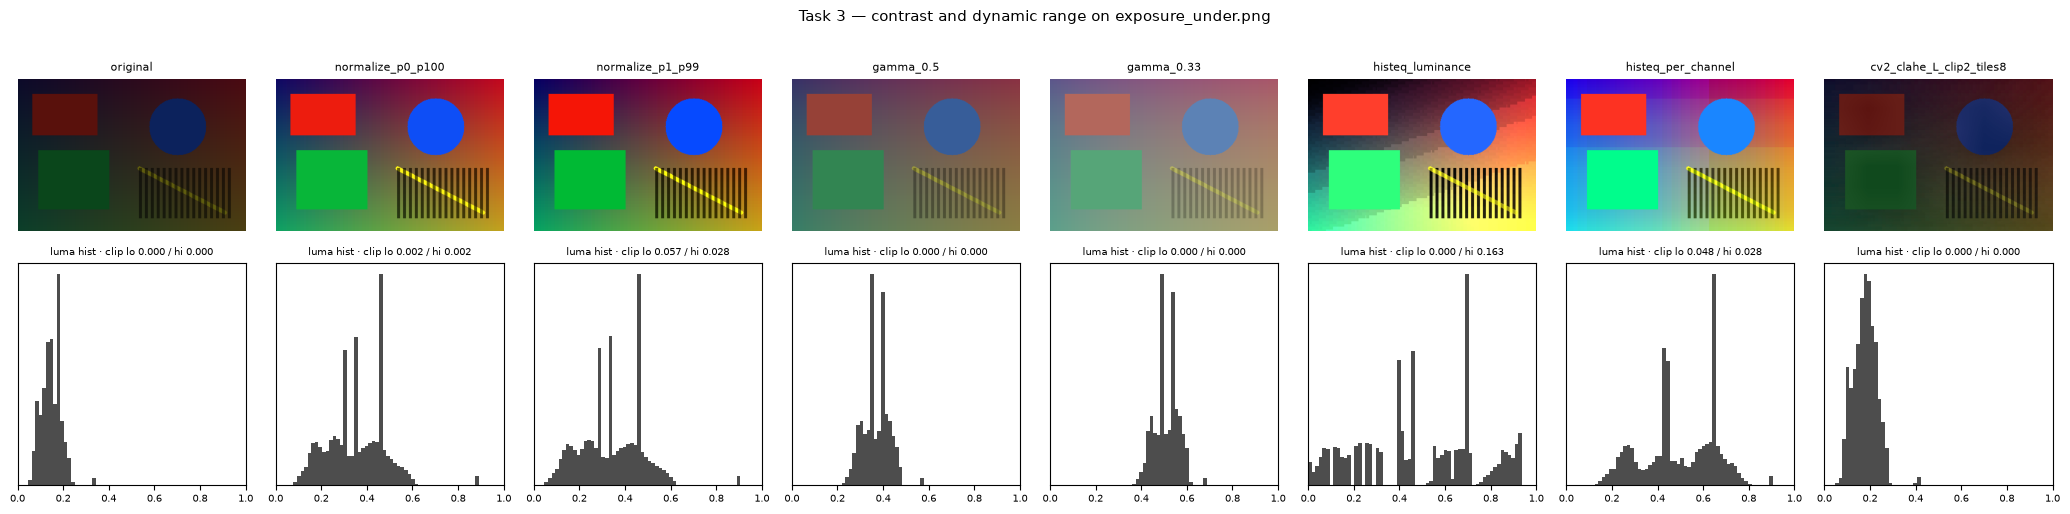

metric,chromaticity_shift,clipped_high_fraction,clipped_low_fraction,hf_residual_std,input_fraction_outside_bounds,luma_entropy,luma_mean,luma_p1,luma_p50,luma_p99,luma_std,noise_amplification_ratio
method,,,,,,,,,,,,
cv2_clahe_L_clip2_tiles8,0.0257,0.0000,0.0000,0.0123,NaN,5.5857,0.1782,0.0827,0.1790,0.2760,0.0503,1.3288
gamma_0.33,0.0956,0.0000,0.0000,0.0106,NaN,5.1728,0.5106,0.3965,0.5094,0.6085,0.0517,1.1432
gamma_0.5,0.0701,0.0000,0.0000,0.0115,NaN,5.3449,0.3704,0.2517,0.3661,0.4769,0.0552,1.2463
histeq_luminance,0.0115,0.1627,0.0005,0.0554,NaN,5.6171,0.4896,0.0118,0.4631,0.9301,0.2660,5.9819
histeq_per_channel,0.0631,0.0283,0.0476,0.0310,NaN,6.4352,0.4958,0.1766,0.4813,0.7760,0.1591,3.3501
normalize_p0_p100,0.0368,0.0020,0.0020,0.0268,NaN,6.2101,0.3530,0.1144,0.3518,0.5953,0.1223,2.8977
normalize_p1_p99,0.0594,0.0283,0.0568,0.0286,0.0091,6.2724,0.3422,0.0862,0.3410,0.6023,0.1309,3.0869
normalize_p2_p98,0.0594,0.0283,0.0568,0.0286,0.0091,6.2724,0.3422,0.0862,0.3410,0.6023,0.1309,3.0869
original,0.0000,0.0000,0.0000,0.0093,NaN,4.9872,0.1493,0.0669,0.1489,0.2329,0.0422,1.0000


In [5]:
# ---- Task 3: contrast and dynamic range ---------------------------------------------------
under = a2_tools.to_float01(images["exposure_under.png"])


def luminance(rgb):
    """Rec.601 luma of a float RGB image (same weights as cv2 RGB2GRAY)."""
    return (0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]).astype(np.float32)


def to_uint8(img):
    return np.round(np.clip(img, 0, 1) * 255).astype(np.uint8)


def equalize_luminance(rgb):
    """Equalize only luma, then rescale each channel by the luma gain (preserves hue ratios)."""
    lum = luminance(rgb)
    eq = sc.histogram_equalize_gray(to_uint8(lum)).astype(np.float32) / 255.0
    gain = eq / np.maximum(lum, 1e-4)
    return np.clip(rgb * gain[..., None], 0, 1).astype(np.float32)


def equalize_per_channel(rgb):
    """Equalize R, G, B independently (changes color balance)."""
    return np.stack([sc.histogram_equalize_gray(to_uint8(rgb[..., c])).astype(np.float32) / 255.0 for c in range(3)], axis=-1)


def clahe_luminance(rgb, clip=2.0, tiles=8):
    """Library comparison only: cv2.createCLAHE applied to the L channel of Lab."""
    lab = cv2.cvtColor(to_uint8(rgb), cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles, tiles))
    lab[..., 0] = clahe.apply(lab[..., 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB).astype(np.float32) / 255.0


def tonal_stats(name, out, src=under):
    """Clipping, tonal distribution, and noise-amplification measurements for one result."""
    lum = luminance(out)
    src_lum = luminance(src)
    # Noise amplification proxy: std of the high-frequency residual (image - Gaussian blur, sigma 1).
    resid = lum - sc.convolve2d_manual(lum, sc.gaussian_kernel(7, 1.0), "reflect")
    src_resid = src_lum - sc.convolve2d_manual(src_lum, sc.gaussian_kernel(7, 1.0), "reflect")
    hist = np.bincount(to_uint8(lum).ravel(), minlength=256) / lum.size
    entropy = float(-np.sum(hist[hist > 0] * np.log2(hist[hist > 0])))
    p1, p50, p99 = np.percentile(lum, [1, 50, 99])
    # Colour shift relative to the source: mean absolute change of chromaticity (channel / sum).
    chroma_src = src / np.maximum(src.sum(-1, keepdims=True), 1e-4)
    chroma_out = out / np.maximum(out.sum(-1, keepdims=True), 1e-4)
    return [
        dict(experiment="contrast", method=name, condition="exposure_under", metric="clipped_low_fraction", value=float(np.mean(out <= 0)), units="fraction"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="clipped_high_fraction", value=float(np.mean(out >= 1)), units="fraction"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_mean", value=float(lum.mean()), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_std", value=float(lum.std()), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_p1", value=float(p1), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_p50", value=float(p50), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_p99", value=float(p99), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="luma_entropy", value=entropy, units="bits"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="hf_residual_std", value=float(resid.std()), units="intensity"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="noise_amplification_ratio", value=float(resid.std() / max(src_resid.std(), 1e-8)), units="ratio"),
        dict(experiment="contrast", method=name, condition="exposure_under", metric="chromaticity_shift", value=float(np.mean(np.abs(chroma_out - chroma_src))), units="ratio"),
    ]


methods = {
    "original": under,
    "normalize_p0_p100": sc.normalize_contrast(under, 0, 100),
    "normalize_p1_p99": sc.normalize_contrast(under, 1, 99),
    "normalize_p2_p98": sc.normalize_contrast(under, 2, 98),
    "gamma_0.5": sc.apply_gamma(under, 0.5),
    "gamma_0.33": sc.apply_gamma(under, 1 / 3),
    "histeq_luminance": equalize_luminance(under),
    "histeq_per_channel": equalize_per_channel(under),
    "cv2_clahe_L_clip2_tiles8": clahe_luminance(under),
}
records = []
for name, out in methods.items():
    records += tonal_stats(name, out)
# Source-side clipping caused by percentile normalization: fraction of input values outside the chosen bounds.
for lo, hi in ((1, 99), (2, 98)):
    lo_v, hi_v = np.percentile(under, [lo, hi])
    records.append(dict(experiment="contrast", method=f"normalize_p{lo}_p{hi}", condition="exposure_under",
                        metric="input_fraction_outside_bounds", value=float(np.mean((under < lo_v) | (under > hi_v))), units="fraction"))
metrics_df = append_metrics(records)

# Figure: image row + luma-histogram row for the original and seven enhancement results.
show = ["original", "normalize_p0_p100", "normalize_p1_p99", "gamma_0.5", "gamma_0.33", "histeq_luminance", "histeq_per_channel", "cv2_clahe_L_clip2_tiles8"]
fig, axes = a2_tools.axes_grid(2, len(show), scale=2.6)
for col, name in enumerate(show):
    out = methods[name]
    axes[0][col].imshow(np.clip(out, 0, 1)); axes[0][col].set_title(name, fontsize=8); axes[0][col].axis("off")
    axes[1][col].hist(luminance(out).ravel(), bins=64, range=(0, 1), color="0.3")
    axes[1][col].set_xlim(0, 1); axes[1][col].set_yticks([]); axes[1][col].tick_params(labelsize=7)
    axes[1][col].set_title(f"luma hist · clip lo {np.mean(out <= 0):.3f} / hi {np.mean(out >= 1):.3f}", fontsize=7)
fig.suptitle("Task 3 — contrast and dynamic range on exposure_under.png", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "contrast_enhancement.png", dpi=150, bbox_inches="tight")
plt.show()

view = metrics_df[metrics_df["experiment"] == "contrast"]
display(view.pivot_table(index="method", columns="metric", values="value").round(4))


**Contrast analysis (3–5 sentences):** Tie visible changes to clipped fractions or tonal measurements and state one limitation.

# **TO DO: WRITE ANALYSIS**


### Task 4 — Gaussian and Laplacian pyramids (8 implementation + 4 evidence points)

Implement all three pyramid functions with finest-to-coarsest ordering, multi-channel support, and correct reconstruction for odd dimensions. Approved resizing operations are permitted; pyramid logic remains student work. Build the saved artifacts from `color_scene.png` with `levels = 4`, and record that file name as `source_image` alongside `levels` in `pyramid_metrics.json`; you may show additional images as well. Save `pyramid_visualization.png`, `pyramid_reconstruction.png`, and `pyramid_metrics.json` containing the required reconstruction fields documented in the README.


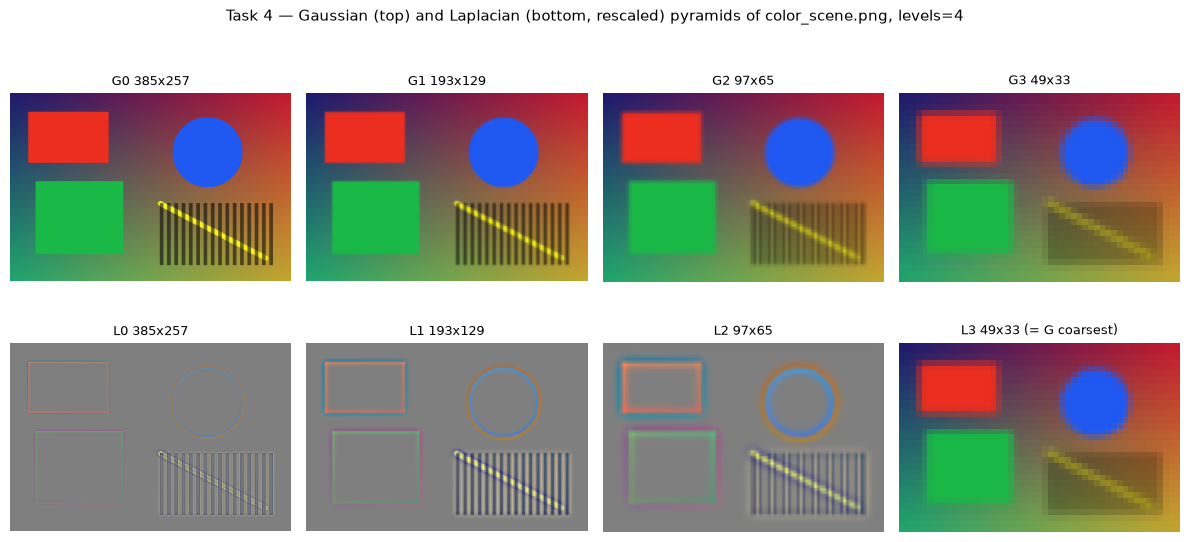

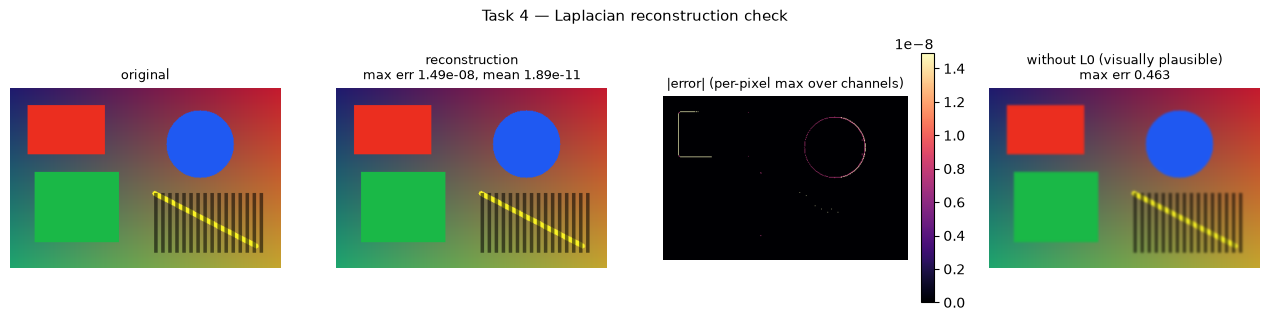

{
  "source_image": "color_scene.png",
  "levels": 4,
  "level_shapes": [
    [
      257,
      385,
      3
    ],
    [
      129,
      193,
      3
    ],
    [
      65,
      97,
      3
    ],
    [
      33,
      49,
      3
    ]
  ],
  "laplacian_level_shapes": [
    [
      257,
      385,
      3
    ],
    [
      129,
      193,
      3
    ],
    [
      65,
      97,
      3
    ],
    [
      33,
      49,
      3
    ]
  ],
  "reconstruction": {
    "max_abs_error": 1.4901161193847656e-08,
    "mean_abs_error": 1.8900355239215294e-11,
    "dtype": "float32",
    "psnr_db": 186.4141920946956
  },
  "reduction": "cv2.pyrDown (Gaussian prefilter, ceiling halving)",
  "expansion": "cv2.pyrUp to the recorded finer shape"
}


metric                                                   max_abs_error  \
method                    condition                                      
laplacian_band_energy     color_scene.png_level0                   NaN   
                          color_scene.png_level1                   NaN   
                          color_scene.png_level2                   NaN   
                          color_scene.png_level3                   NaN   
laplacian_reconstruction  color_scene.png_levels2         1.490116e-08   
                          color_scene.png_levels3         1.490116e-08   
                          color_scene.png_levels4         1.490116e-08   
                          color_scene.png_levels5         1.490116e-08   
                          color_scene.png_levels6         1.490116e-08   
                          test_pattern_gray.png_levels2   1.490116e-08   
                          test_pattern_gray.png_levels3   5.960464e-08   
                          test_pattern_gray.png_levels4   5.960464e-08   
                          test_pattern_gray.png_levels5   5.960464e-08   
                          test_pattern_gray.png_levels6   5.960464e-08   
reconstruction_without_L0 color_scene.png_levels4         4.631281e-01   

metric                                                   mean_abs_error  \
method                    condition                                       
laplacian_band_energy     color_scene.png_level0                    NaN   
                          color_scene.png_level1                    NaN   
                          color_scene.png_level2                    NaN   
                          color_scene.png_level3                    NaN   
laplacian_reconstruction  color_scene.png_levels2          1.877485e-11   
                          color_scene.png_levels3          1.890036e-11   
                          color_scene.png_levels4          1.890036e-11   
                          color_scene.png_levels5          1.890036e-11   
                          color_scene.png_levels6          1.890036e-11   
                          test_pattern_gray.png_levels2    1.051313e-09   
                          test_pattern_gray.png_levels3    1.365463e-09   
                          test_pattern_gray.png_levels4    1.365463e-09   
                          test_pattern_gray.png_levels5    1.365463e-09   
                          test_pattern_gray.png_levels6    1.365463e-09   
reconstruction_without_L0 color_scene.png_levels4          1.250988e-02   

metric                                                        psnr       rms  \
method                    condition                                            
laplacian_band_energy     color_scene.png_level0               NaN  0.036169   
                          color_scene.png_level1               NaN  0.039023   
                          color_scene.png_level2               NaN  0.034659   
                          color_scene.png_level3               NaN  0.430982   
laplacian_reconstruction  color_scene.png_levels2              NaN       NaN   
                          color_scene.png_levels3              NaN       NaN   
                          color_scene.png_levels4              NaN       NaN   
                          color_scene.png_levels5              NaN       NaN   
                          color_scene.png_levels6              NaN       NaN   
                          test_pattern_gray.png_levels2        NaN       NaN   
                          test_pattern_gray.png_levels3        NaN       NaN   
                          test_pattern_gray.png_levels4        NaN       NaN   
                          test_pattern_gray.png_levels5        NaN       NaN   
                          test_pattern_gray.png_levels6        NaN       NaN   
reconstruction_without_L0 color_scene.png_levels4        28.833166       NaN   

metric                                                       ssim  
method                    condition 

In [6]:
# ---- Task 4: Gaussian and Laplacian pyramids ----------------------------------------------
PYR_SOURCE, PYR_LEVELS = "color_scene.png", 4
scene = a2_tools.to_float01(images[PYR_SOURCE])
gauss = sc.gaussian_pyramid(scene, PYR_LEVELS)
lap = sc.laplacian_pyramid(scene, PYR_LEVELS)
recon = sc.reconstruct_laplacian_pyramid(lap)
err = np.abs(recon - scene)


def show_laplacian(level):
    """Rescale a band-pass level for display: zero maps to mid-gray, symmetric range."""
    scale = max(float(np.max(np.abs(level))), 1e-6)
    return np.clip(0.5 + level / (2 * scale), 0, 1)


pyramid_metrics = {
    "source_image": PYR_SOURCE,
    "levels": PYR_LEVELS,
    "level_shapes": [list(g.shape) for g in gauss],
    "laplacian_level_shapes": [list(l.shape) for l in lap],
    "reconstruction": {
        "max_abs_error": float(err.max()),
        "mean_abs_error": float(err.mean()),
        "dtype": str(recon.dtype),
        "psnr_db": float(peak_signal_noise_ratio(scene, np.clip(recon, 0, 1), data_range=1.0)),
    },
    "reduction": "cv2.pyrDown (Gaussian prefilter, ceiling halving)",
    "expansion": "cv2.pyrUp to the recorded finer shape",
}
a2_tools.save_json(PATHS["tables"] / "pyramid_metrics.json", pyramid_metrics)

records = [
    dict(experiment="pyramid", method="laplacian_reconstruction", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="max_abs_error", value=float(err.max()), units="intensity"),
    dict(experiment="pyramid", method="laplacian_reconstruction", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="mean_abs_error", value=float(err.mean()), units="intensity"),
]
# Reconstruction across level counts and on an odd-sized grayscale source.
for name in (PYR_SOURCE, "test_pattern_gray.png"):
    src = a2_tools.to_float01(images[name])
    for L in (2, 3, 4, 5, 6):
        r = sc.reconstruct_laplacian_pyramid(sc.laplacian_pyramid(src, L))
        e = np.abs(r - src)
        records += [
            dict(experiment="pyramid", method="laplacian_reconstruction", condition=f"{name}_levels{L}", metric="max_abs_error", value=float(e.max()), units="intensity"),
            dict(experiment="pyramid", method="laplacian_reconstruction", condition=f"{name}_levels{L}", metric="mean_abs_error", value=float(e.mean()), units="intensity"),
        ]
# Visual plausibility vs correctness: drop the finest band (zero L0) and reconstruct.
lap_dropped = [np.zeros_like(lap[0])] + list(lap[1:])
recon_dropped = sc.reconstruct_laplacian_pyramid(lap_dropped)
records += [
    dict(experiment="pyramid", method="reconstruction_without_L0", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="max_abs_error", value=float(np.max(np.abs(recon_dropped - scene))), units="intensity"),
    dict(experiment="pyramid", method="reconstruction_without_L0", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="mean_abs_error", value=float(np.mean(np.abs(recon_dropped - scene))), units="intensity"),
    dict(experiment="pyramid", method="reconstruction_without_L0", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="psnr", value=float(peak_signal_noise_ratio(scene, np.clip(recon_dropped, 0, 1), data_range=1.0)), units="dB"),
    dict(experiment="pyramid", method="reconstruction_without_L0", condition=f"{PYR_SOURCE}_levels{PYR_LEVELS}", metric="ssim", value=float(structural_similarity(scene, np.clip(recon_dropped, 0, 1), data_range=1.0, channel_axis=-1)), units="index"),
]
# Energy per Laplacian band (what each level carries).
for i, l in enumerate(lap):
    records.append(dict(experiment="pyramid", method="laplacian_band_energy", condition=f"{PYR_SOURCE}_level{i}", metric="rms", value=float(np.sqrt(np.mean(l ** 2))), units="intensity"))
metrics_df = append_metrics(records)

# Figure 1: Gaussian and Laplacian levels at native resolution (axes scaled to each level's size).
fig, axes = a2_tools.axes_grid(2, PYR_LEVELS, scale=3.0)
for i in range(PYR_LEVELS):
    axes[0][i].imshow(np.clip(gauss[i], 0, 1)); axes[0][i].set_title(f"G{i} {gauss[i].shape[1]}x{gauss[i].shape[0]}", fontsize=9); axes[0][i].axis("off")
    disp = show_laplacian(lap[i]) if i < PYR_LEVELS - 1 else np.clip(lap[i], 0, 1)
    axes[1][i].imshow(disp); axes[1][i].set_title(f"L{i} {lap[i].shape[1]}x{lap[i].shape[0]}" + ("" if i < PYR_LEVELS - 1 else " (= G coarsest)"), fontsize=9); axes[1][i].axis("off")
fig.suptitle(f"Task 4 — Gaussian (top) and Laplacian (bottom, rescaled) pyramids of {PYR_SOURCE}, levels={PYR_LEVELS}", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "pyramid_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: original, reconstruction, amplified error map, and the plausible-but-wrong reconstruction without L0.
fig, axes = a2_tools.axes_grid(1, 4, scale=3.2)
axes[0][0].imshow(scene); axes[0][0].set_title("original", fontsize=9)
axes[0][1].imshow(np.clip(recon, 0, 1)); axes[0][1].set_title(f"reconstruction\nmax err {err.max():.2e}, mean {err.mean():.2e}", fontsize=9)
im = axes[0][2].imshow(err.max(-1), cmap="magma"); axes[0][2].set_title("|error| (per-pixel max over channels)", fontsize=9)
fig.colorbar(im, ax=axes[0][2], fraction=0.046)
axes[0][3].imshow(np.clip(recon_dropped, 0, 1)); axes[0][3].set_title(f"without L0 (visually plausible)\nmax err {np.max(np.abs(recon_dropped - scene)):.3f}", fontsize=9)
for ax in axes[0]: ax.axis("off")
fig.suptitle("Task 4 — Laplacian reconstruction check", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "pyramid_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

print(json.dumps(pyramid_metrics, indent=2))
view = metrics_df[metrics_df["experiment"] == "pyramid"]
display(view.pivot_table(index=["method", "condition"], columns="metric", values="value"))


**Pyramid analysis (3–5 sentences):** Explain what different levels represent and use reconstruction error to distinguish mathematical correctness from visual plausibility.

# **TO DO: WRITE ANALYSIS**


## 5. Required Experiments

### Task 5 — direct blending and Laplacian pyramid blending across multiple pairs (7 implementation + 3 evidence points)

Implement `laplacian_pyramid_blend`, where mask 0 selects `image_a`, mask 1 selects `image_b`, and intermediate values blend. The dataset provides four aligned blend pairs spanning five mask geometries: `blend_left`/`blend_right` with `blend_mask` (soft vertical seam) or `blend_mask_spot` (circular seam), `blend2_left`/`blend2_right` with `blend2_mask` (diagonal seam), `blend3_left`/`blend3_right` (real apple/orange photographs) with `blend3_mask` (hard vertical seam), and `blend4_left`/`blend4_right` (a second real apple/orange close-up pair) with `blend4_mask` (hard circular seam). The two real-photo masks are not feathered, so they give the clearest evidence of the difference between the two methods. Apply `laplacian_pyramid_blend` to at least two different image pairs (two mask geometries over the same pair does not count as two), comparing each against direct blending (splicing) using the same mask, and include one deliberately poor mask or configuration (for example, too few pyramid levels or a mask misaligned with the seam) on at least one pair. Save one combined `outputs/figures/blending_comparison.png` arranging results across the pairs you used, and append per-pair seam or transition evidence to the cumulative metrics file.

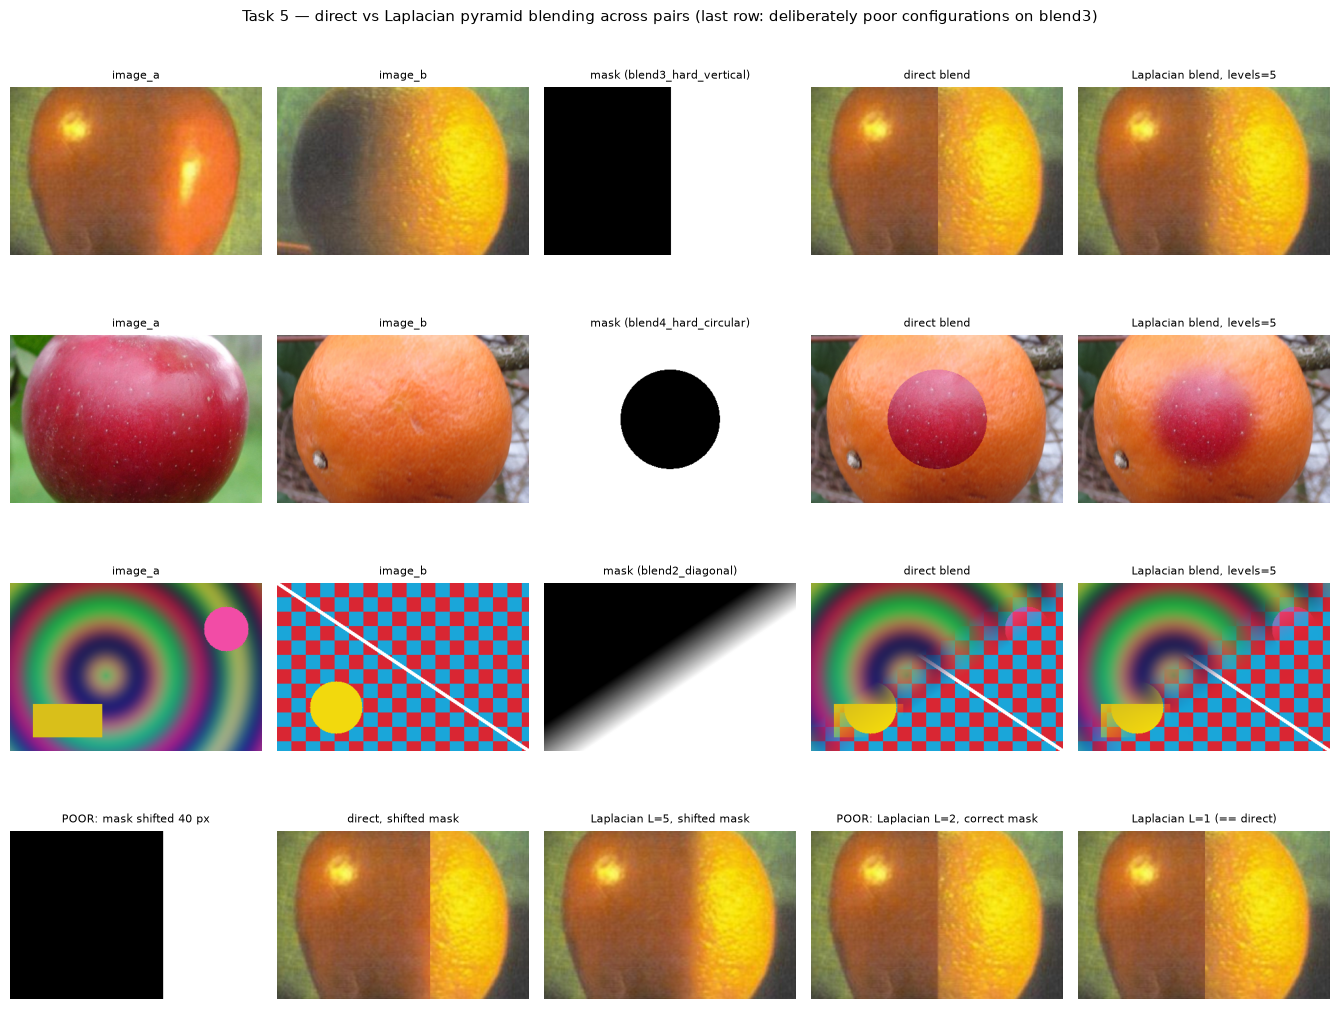

method,direct_blend,laplacian_blend_levels1,laplacian_blend_levels2,laplacian_blend_levels3,laplacian_blend_levels5,laplacian_blend_levels7
condition,,,,,,
blend2_diagonal,0.0135,0.0135,0.0135,0.0134,0.0133,0.0132
blend3_hard_vertical,0.0263,0.0263,0.0228,0.0182,0.0109,0.0098
blend3_mask_shifted40px,0.0293,NaN,NaN,NaN,0.0109,NaN
blend4_hard_circular,0.0317,0.0317,0.0254,0.0206,0.0128,0.0119


In [7]:
# ---- Task 5: direct blending vs Laplacian pyramid blending across pairs -------------------
BLEND_LEVELS = 5
pairs = {
    "blend3_hard_vertical": ("blend3_left.png", "blend3_right.png", "blend3_mask.png"),
    "blend4_hard_circular": ("blend4_left.png", "blend4_right.png", "blend4_mask.png"),
    "blend2_diagonal": ("blend2_left.png", "blend2_right.png", "blend2_mask.png"),
}


def direct_blend(a, b, m):
    return ((1 - m[..., None]) * a + m[..., None] * b).astype(np.float32)


def seam_band(mask, width=7):
    """Pixels within `width` of the mask transition (where the mask changes)."""
    gy, gx = np.gradient(mask.astype(np.float64))
    edge = (np.sqrt(gx ** 2 + gy ** 2) > 0.01).astype(np.uint8)
    return cv2.dilate(edge, np.ones((width, width), np.uint8)).astype(bool)


def seam_metrics(name, method, out, band, a, b):
    """Gradient energy inside the seam band, relative to the sources' own energy there."""
    lum_out = luminance(out)
    src_energy = 0.5 * (edge_energy_masked(luminance(a), band) + edge_energy_masked(luminance(b), band))
    out_energy = edge_energy_masked(lum_out, band)
    return [
        dict(experiment="blending", method=method, condition=name, metric="seam_band_gradient", value=out_energy, units="intensity/px"),
        dict(experiment="blending", method=method, condition=name, metric="seam_band_gradient_ratio_vs_sources", value=out_energy / max(src_energy, 1e-8), units="ratio"),
        dict(experiment="blending", method=method, condition=name, metric="seam_band_fraction", value=float(band.mean()), units="fraction"),
    ]


def edge_energy_masked(img, band):
    gy, gx = np.gradient(img.astype(np.float64))
    return float(np.mean(np.sqrt(gx ** 2 + gy ** 2)[band]))


records, results = [], {}
for name, (fa, fb, fm) in pairs.items():
    a, b = a2_tools.to_float01(images[fa]), a2_tools.to_float01(images[fb])
    m = a2_tools.to_float01(images[fm])
    band = seam_band(m)
    d = direct_blend(a, b, m)
    p = sc.laplacian_pyramid_blend(a, b, m, BLEND_LEVELS)
    results[name] = dict(a=a, b=b, m=m, direct=d, pyramid=p)
    records += seam_metrics(name, "direct_blend", d, band, a, b)
    records += seam_metrics(name, f"laplacian_blend_levels{BLEND_LEVELS}", p, band, a, b)
    for L in (1, 2, 3, 7):  # level-count sweep; levels=1 degenerates to direct blending
        pL = sc.laplacian_pyramid_blend(a, b, m, L)
        records += seam_metrics(name, f"laplacian_blend_levels{L}", pL, band, a, b)[:2]
        results[name][f"levels{L}"] = pL

# Deliberately poor configurations on the hard vertical real-photo pair: a mask shifted 40 px off the seam,
# and too few pyramid levels with the correct mask.
r3 = results["blend3_hard_vertical"]
shift = 40
m_bad = np.roll(r3["m"], shift, axis=1); m_bad[:, :shift] = r3["m"][:, :1]
band_bad = seam_band(m_bad)
bad_direct = direct_blend(r3["a"], r3["b"], m_bad)
bad_pyr = sc.laplacian_pyramid_blend(r3["a"], r3["b"], m_bad, BLEND_LEVELS)
records += seam_metrics("blend3_mask_shifted40px", "direct_blend", bad_direct, band_bad, r3["a"], r3["b"])
records += seam_metrics("blend3_mask_shifted40px", f"laplacian_blend_levels{BLEND_LEVELS}", bad_pyr, band_bad, r3["a"], r3["b"])
metrics_df = append_metrics(records)

# Figure: one row per pair (A, B, mask, direct, pyramid) plus a row of poor configurations.
fig, axes = a2_tools.axes_grid(len(pairs) + 1, 5, scale=2.7)
for row, (name, r) in enumerate(results.items()):
    panels = [("image_a", r["a"]), ("image_b", r["b"]), (f"mask ({name})", r["m"]),
              ("direct blend", r["direct"]), (f"Laplacian blend, levels={BLEND_LEVELS}", r["pyramid"])]
    for ax, (title, img) in zip(axes[row], panels):
        ax.imshow(np.clip(img, 0, 1), cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")
poor = [("POOR: mask shifted 40 px", m_bad), ("direct, shifted mask", bad_direct), (f"Laplacian L={BLEND_LEVELS}, shifted mask", bad_pyr),
        ("POOR: Laplacian L=2, correct mask", r3["levels2"]), ("Laplacian L=1 (== direct)", r3["levels1"])]
for ax, (title, img) in zip(axes[-1], poor):
    ax.imshow(np.clip(img, 0, 1), cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")
fig.suptitle("Task 5 — direct vs Laplacian pyramid blending across pairs (last row: deliberately poor configurations on blend3)", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "blending_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

view = metrics_df[(metrics_df["experiment"] == "blending") & (metrics_df["metric"] == "seam_band_gradient")]
display(view.pivot_table(index="condition", columns="method", values="value").round(4))


**Blending analysis (3–5 sentences):** Discuss seam visibility, low- and high-frequency transitions, mask design, and boundary artifacts.

# **TO DO: WRITE ANALYSIS**


### Task 6 — pyramid decomposition visualization (4 evidence + 2 analysis points)

For one synthetic pair and one real-photo pair (state which you used), use your already-implemented `gaussian_pyramid`, `laplacian_pyramid`, and `laplacian_pyramid_blend` to make the blending process itself visible instead of only its result. For each pair, show: the Gaussian pyramid of each source image; the Laplacian pyramid of each source image, rescaled per level so the band-pass structure is visible instead of near-black; the blended Laplacian pyramid produced by combining each level with the mask's Gaussian pyramid; and the progressive reconstruction from the coarsest level up to the final full-resolution blend. Save one combined `outputs/figures/pyramid_decomposition.png` arranging both pairs. This task exercises functions you already implemented in Tasks 4 and 5 — no new graded function is required.

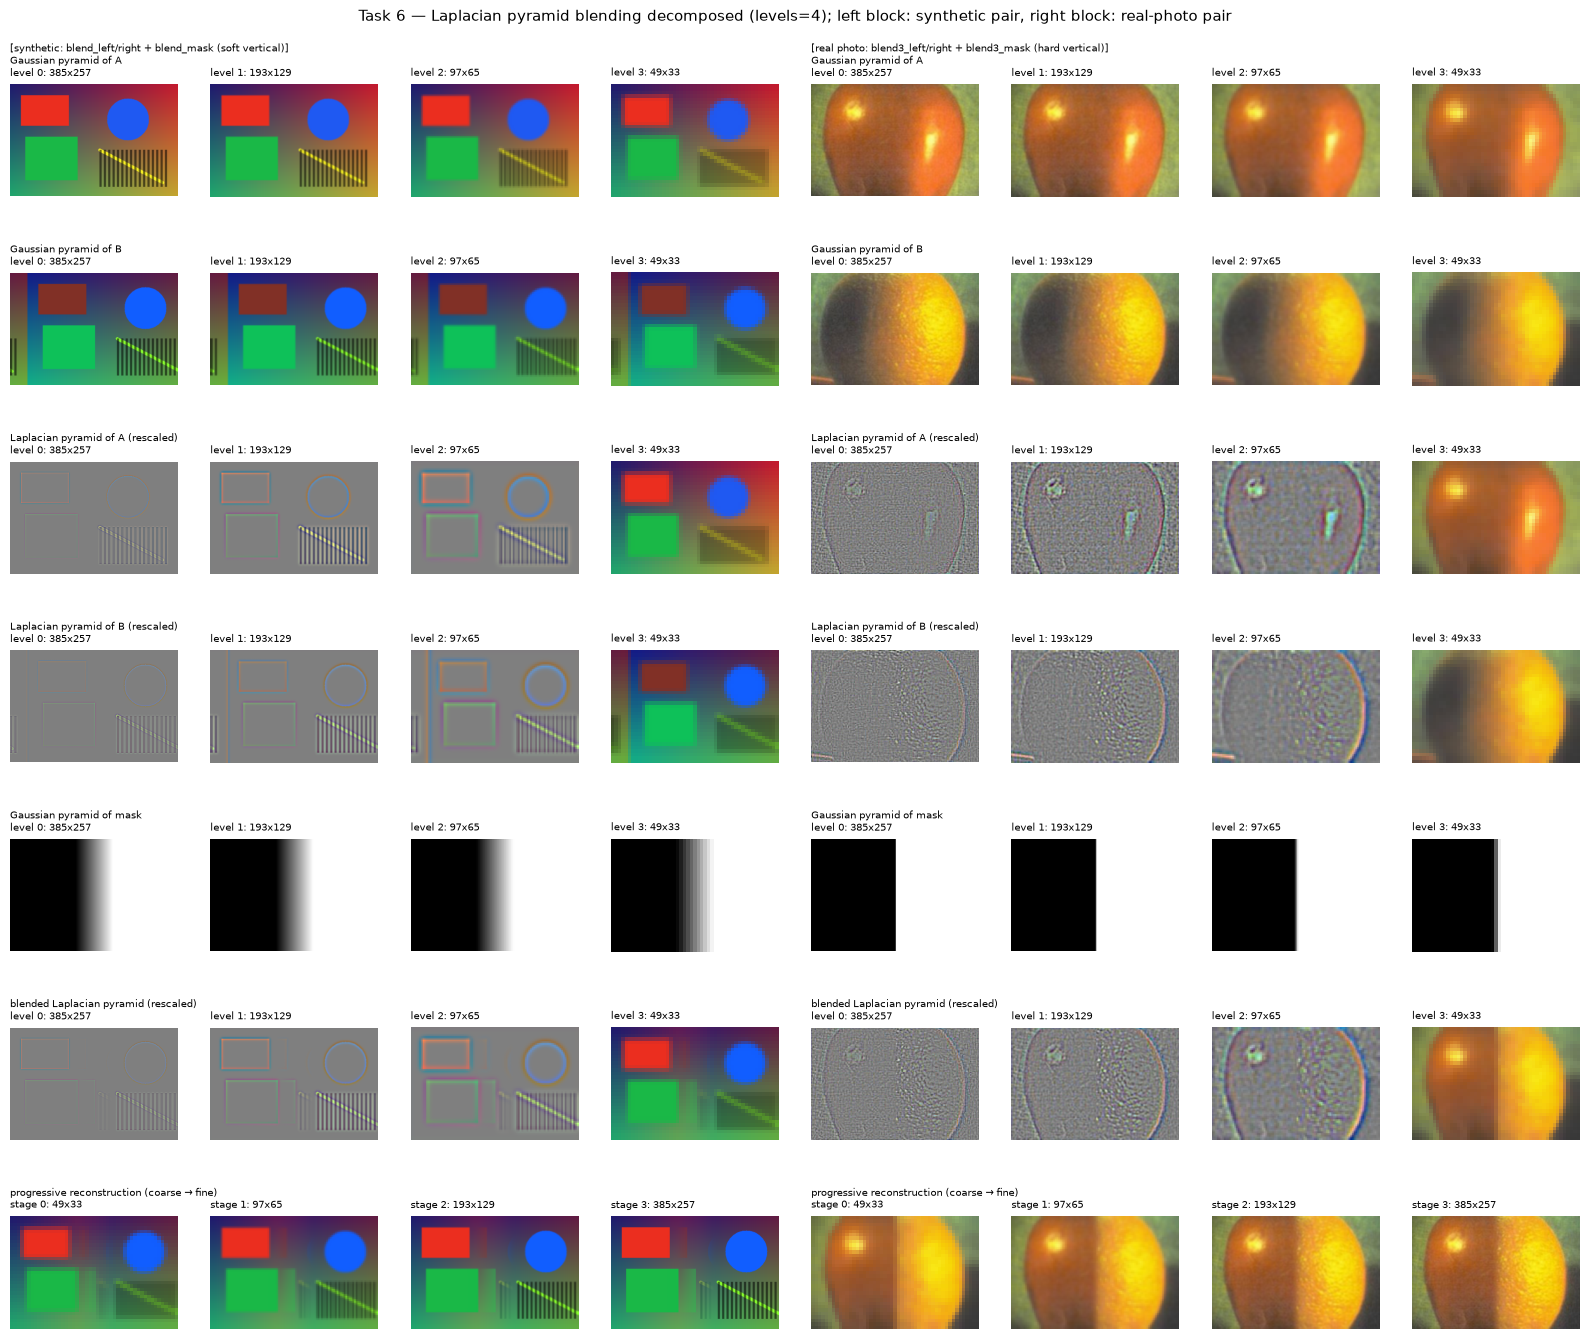

In [8]:
# ---- Task 6: pyramid decomposition visualization ------------------------------------------
DECOMP_LEVELS = 4
decomp_pairs = {
    "synthetic: blend_left/right + blend_mask (soft vertical)": ("blend_left.png", "blend_right.png", "blend_mask.png"),
    "real photo: blend3_left/right + blend3_mask (hard vertical)": ("blend3_left.png", "blend3_right.png", "blend3_mask.png"),
}


def decompose_blend(a, b, m, levels):
    """Expose every stage of laplacian_pyramid_blend using the Task 4/5 functions."""
    ga, gb = sc.gaussian_pyramid(a, levels), sc.gaussian_pyramid(b, levels)
    la, lb = sc.laplacian_pyramid(a, levels), sc.laplacian_pyramid(b, levels)
    gm = sc.gaussian_pyramid(m, levels)
    blended = [((1 - w[..., None]) * x + w[..., None] * y).astype(np.float32) for x, y, w in zip(la, lb, gm)]
    progressive = [blended[-1]]  # coarsest level first, then each expand-and-add step
    for level in reversed(blended[:-1]):
        progressive.append(sc.expand_image(progressive[-1], level.shape) + level)
    final = sc.laplacian_pyramid_blend(a, b, m, levels)
    assert np.max(np.abs(progressive[-1] - final)) < 1e-5  # the staged path reproduces the graded function
    return dict(ga=ga, gb=gb, la=la, lb=lb, gm=gm, blended=blended, progressive=progressive)


row_titles = ["Gaussian pyramid of A", "Gaussian pyramid of B", "Laplacian pyramid of A (rescaled)", "Laplacian pyramid of B (rescaled)",
              "Gaussian pyramid of mask", "blended Laplacian pyramid (rescaled)", "progressive reconstruction (coarse → fine)"]
fig, axes = a2_tools.axes_grid(len(row_titles), 2 * DECOMP_LEVELS, scale=2.0)
for pair_idx, (label, (fa, fb, fm)) in enumerate(decomp_pairs.items()):
    a, b, m = (a2_tools.to_float01(images[f]) for f in (fa, fb, fm))
    d = decompose_blend(a, b, m, DECOMP_LEVELS)
    col0 = pair_idx * DECOMP_LEVELS
    rows = [d["ga"], d["gb"], d["la"], d["lb"], d["gm"], d["blended"], d["progressive"]]
    for r, (title, seq) in enumerate(zip(row_titles, rows)):
        for i in range(DECOMP_LEVELS):
            ax = axes[r][col0 + i]
            img = seq[i]
            is_bandpass = title.startswith(("Laplacian", "blended")) and i < DECOMP_LEVELS - 1
            disp = show_laplacian(img) if is_bandpass else np.clip(img, 0, 1)
            ax.imshow(disp, cmap="gray" if disp.ndim == 2 else None, vmin=0, vmax=1)
            if r == 6:
                sub = f"stage {i}: {img.shape[1]}x{img.shape[0]}"
            else:
                sub = f"level {i}: {img.shape[1]}x{img.shape[0]}"
            head = (f"[{label}]\n" if (r == 0 and i == 0) else "") + (title + "\n" if i == 0 else "")
            ax.set_title(head + sub, fontsize=7, loc="left")
            ax.axis("off")
fig.suptitle(f"Task 6 — Laplacian pyramid blending decomposed (levels={DECOMP_LEVELS}); left block: synthetic pair, right block: real-photo pair", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "pyramid_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()


**Decomposition analysis (2–4 sentences):** Explain what a Laplacian pyramid level represents, why blending per level instead of blending final pixel values directly avoids a visible seam, and connect this to the reconstruction check from Task 4.

# **TO DO: WRITE ANALYSIS**

## 6. Results and Analysis

The immediate experiment responses contribute **10 analysis points collectively**. The synthesis contributes **3 points**. In at most 180 words, connect the most important filtering tradeoff, the strongest multi-scale finding, and one limitation. Do not restate each earlier observation.


**Synthesis:** YOUR RESPONSE.

# **TO DO: WRITE ANALYSIS**


## 7. Failure Analysis

### Task 7 — two controlled failures (5 points, counted under analysis and interpretation)

Show two reproducible failures from different topics. For each, identify the failure, show evidence, explain its mechanism, correct or mitigate it, and verify the improvement. The approved fallback is an excessively large sharpening amount that produces halos around strong edges, followed by a reduced or reformulated configuration. Students may instead use another reproducible failure. Save one coherent `outputs/figures/failure_analysis.png` and append `failure` rows to `experiment_metrics.csv` that quantify each failure and its mitigation.


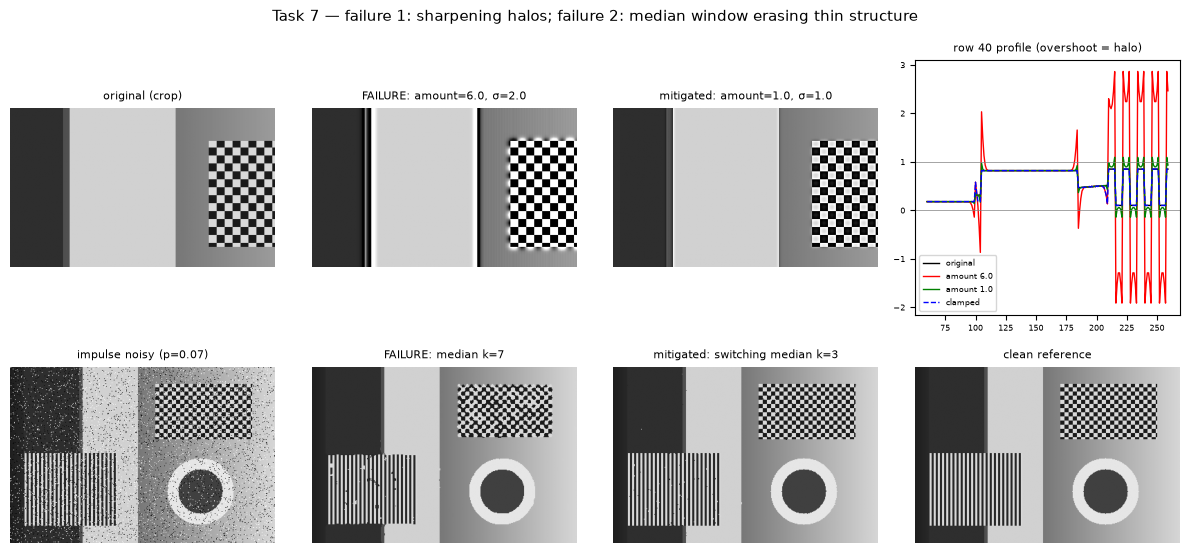

metric                                                   edge_energy_ratio  \
method             condition                                                 
median_detail_loss failure_median_k7                                   NaN   
                   mitigated_median_k3                                 NaN   
                   mitigated_switching_median_k3                       NaN   
                   noisy_input_impulse_p0.07                           NaN   
sharpen_halo       failure_amount6.0_sigma2.0                       6.6427   
                   mitigated_amount1.0_sigma1.0                     1.5581   
                   mitigated_clamped_amount6.0_sigma2.0             1.0432   

metric                                                   edge_energy_ratio_vs_clean  \
method             condition                                                          
median_detail_loss failure_median_k7                                         0.8957   
                   mitigated_median_k3                                       0.9918   
                   mitigated_switching_median_k3                             1.0027   
                   noisy_input_impulse_p0.07                                 1.8279   
sharpen_halo       failure_amount6.0_sigma2.0                                   NaN   
                   mitigated_amount1.0_sigma1.0                                 NaN   
                   mitigated_clamped_amount6.0_sigma2.0                         NaN   

metric                                                   halo_amplitude  \
method             condition                                              
median_detail_loss failure_median_k7                                NaN   
                   mitigated_median_k3                              NaN   
                   mitigated_switching_median_k3                    NaN   
                   noisy_input_impulse_p0.07                        NaN   
sharpen_halo       failure_amount6.0_sigma2.0                    3.1401   
                   mitigated_amount1.0_sigma1.0                  0.2856   
                   mitigated_clamped_amount6.0_sigma2.0          0.0000   

metric                                                   max_value  min_value  \
method             condition                                                    
median_detail_loss failure_median_k7                           NaN        NaN   
                   mitigated_median_k3                         NaN        NaN   
                   mitigated_switching_median_k3               NaN        NaN   
                   noisy_input_impulse_p0.07                   NaN        NaN   
sharpen_halo       failure_amount6.0_sigma2.0               3.7352    -3.1401   
                   mitigated_amount1.0_sigma1.0             1.2023    -0.2856   
                   mitigated_clamped_amount6.0_sigma2.0     0.9020     0.1020   

metric                                                   overshoot_fraction  \
method             condition                                                  
median_detail_loss failure_median_k7                                    NaN   
                   mitigated_median_k3                                  NaN   
                   mitigated_switching_median_k3                        NaN   
                   noisy_input_impulse_p0.07                            NaN   
sharpen_halo       failure_amount6.0_sigma2.0                        0.3232   
                   mitigated_amount1.0_sigma1.0                      0.1650   
                   mitigated_clamped_amount6.0_sigma2.0              0.0000   

metric                                                      psnr  \
method             condition                                       
median_detail_loss failure_median_k7                     11.3297   
                   mitigated_median_k3                   25.1626   
                   mitigated_switching_median_k3         30.8518   
                   noisy_input_impulse_p0.07           

In [9]:
# ---- Task 7: two controlled failures ------------------------------------------------------
records = []

# Failure 1 (sharpening): an excessive unsharp amount produces halos (overshoot beyond [0,1]) around strong edges.
FAIL_AMOUNT, FAIL_SIGMA = 6.0, 2.0
FIX_AMOUNT, FIX_SIGMA = 1.0, 1.0
sharp_fail = sc.sharpen_image(gray, FAIL_AMOUNT, FAIL_SIGMA)
sharp_fix = sc.sharpen_image(gray, FIX_AMOUNT, FIX_SIGMA)
# Reformulated alternative: keep the amount but clamp the result to the local min/max of the original
# inside the blur support, which removes overshoot while keeping the steeper edge.
support = sc.gaussian_support(FAIL_SIGMA)
kernel_box = np.ones((support, support), np.uint8)
local_min, local_max = cv2.erode(gray, kernel_box), cv2.dilate(gray, kernel_box)
sharp_clamped = np.clip(sc.sharpen_image(gray, FAIL_AMOUNT, FAIL_SIGMA), local_min, local_max).astype(np.float32)
profile_row = 40  # crosses the dark block / light background step edge above the stripes


def halo_stats(cond, out):
    return [
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="overshoot_fraction", value=float(np.mean((out > 1) | (out < 0))), units="fraction"),
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="max_value", value=float(out.max()), units="intensity"),
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="min_value", value=float(out.min()), units="intensity"),
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="halo_amplitude", value=float(max(out.max() - 1.0, 0.0 - out.min(), 0.0)), units="intensity"),
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="edge_energy_ratio", value=edge_energy(out) / edge_energy(gray), units="ratio"),
        dict(experiment="failure", method="sharpen_halo", condition=cond, metric="ssim_vs_original", value=float(structural_similarity(gray, np.clip(out, 0, 1), data_range=1.0)), units="index"),
    ]


records += halo_stats(f"failure_amount{FAIL_AMOUNT}_sigma{FAIL_SIGMA}", sharp_fail)
records += halo_stats(f"mitigated_amount{FIX_AMOUNT}_sigma{FIX_SIGMA}", sharp_fix)
records += halo_stats(f"mitigated_clamped_amount{FAIL_AMOUNT}_sigma{FAIL_SIGMA}", sharp_clamped)

# Failure 2 (denoising): a too-large median window on impulse noise erases thin stripes and the checkerboard,
# scoring below the noisy input. Mitigation: a small window, and a switching median that only replaces
# pixels detected as impulses (exactly 0 or 1) so untouched pixels keep their detail.
imp = noisy["impulse"]
med_fail = sc.median_filter_manual(imp, 7)
med_fix = sc.median_filter_manual(imp, 3)
impulse_mask = (imp <= 0.0) | (imp >= 1.0)
med_switch = np.where(impulse_mask, med_fix, imp).astype(np.float32)


def denoise_stats(cond, out):
    q = quality(clean, out)
    return [
        dict(experiment="failure", method="median_detail_loss", condition=cond, metric="psnr", value=q["psnr"], units="dB"),
        dict(experiment="failure", method="median_detail_loss", condition=cond, metric="ssim", value=q["ssim"], units="index"),
        dict(experiment="failure", method="median_detail_loss", condition=cond, metric="rmse", value=q["rmse"], units="intensity"),
        dict(experiment="failure", method="median_detail_loss", condition=cond, metric="edge_energy_ratio_vs_clean", value=edge_energy(out) / edge_energy(clean), units="ratio"),
    ]


records += denoise_stats("noisy_input_impulse_p0.07", imp)
records += denoise_stats("failure_median_k7", med_fail)
records += denoise_stats("mitigated_median_k3", med_fix)
records += denoise_stats("mitigated_switching_median_k3", med_switch)
records.append(dict(experiment="failure", method="median_detail_loss", condition="mitigated_switching_median_k3", metric="replaced_fraction", value=float(impulse_mask.mean()), units="fraction"))
metrics_df = append_metrics(records)

# Figure: row 1 sharpening halo (with an intensity profile), row 2 median detail loss.
fig, axes = a2_tools.axes_grid(2, 4, scale=3.0)
crop = (slice(0, 120), slice(60, 260))
for ax, (title, img) in zip(axes[0][:3], [("original (crop)", gray), (f"FAILURE: amount={FAIL_AMOUNT}, σ={FAIL_SIGMA}", sharp_fail),
                                          (f"mitigated: amount={FIX_AMOUNT}, σ={FIX_SIGMA}", sharp_fix)]):
    ax.imshow(np.clip(img[crop], 0, 1), cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")
ax = axes[0][3]; xs = np.arange(60, 260)
ax.plot(xs, gray[profile_row, 60:260], "k", lw=1, label="original")
ax.plot(xs, sharp_fail[profile_row, 60:260], "r", lw=1, label=f"amount {FAIL_AMOUNT}")
ax.plot(xs, sharp_fix[profile_row, 60:260], "g", lw=1, label=f"amount {FIX_AMOUNT}")
ax.plot(xs, sharp_clamped[profile_row, 60:260], "b--", lw=1, label="clamped")
ax.axhline(1, color="0.5", lw=0.5); ax.axhline(0, color="0.5", lw=0.5)
ax.set_title(f"row {profile_row} profile (overshoot = halo)", fontsize=8); ax.legend(fontsize=6); ax.tick_params(labelsize=6)
for ax, (title, img) in zip(axes[1], [("impulse noisy (p=0.07)", imp), ("FAILURE: median k=7", med_fail),
                                      ("mitigated: switching median k=3", med_switch), ("clean reference", clean)]):
    ax.imshow(np.clip(img, 0, 1), cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")
fig.suptitle("Task 7 — failure 1: sharpening halos; failure 2: median window erasing thin structure", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["figures"] / "failure_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

view = metrics_df[metrics_df["experiment"] == "failure"]
display(view.pivot_table(index=["method", "condition"], columns="metric", values="value").round(4))


**Failure analysis:** YOUR RESPONSE.

# **TO DO: WRITE ANALYSIS**


## 8. Extension

### Task 8 — Extension (5 points)

Choose one: compare an approved advanced denoiser; alternative-color-space sharpening; local contrast enhancement; frequency-domain filtering; hybrid image; pyramid-mask comparison; small focus stack; or an approved enhancement. Submit one declared principal artifact under `outputs/extension/`, include one baseline comparison, and give a concise evidence-based explanation. Approved means anything you can build from the packages already imported in Section 2 (NumPy, OpenCV, scikit-image, Matplotlib, pandas). Use no additional packages or pretrained models.


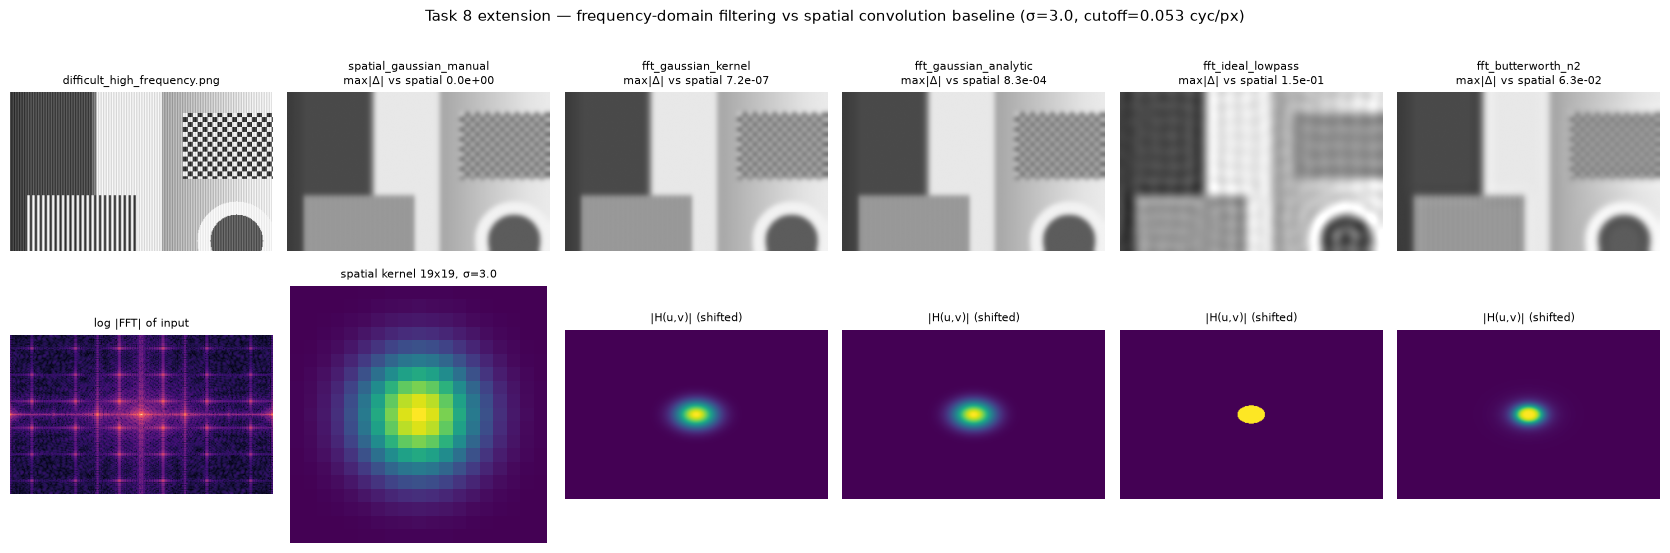

Declared extension artifact: outputs/extension/frequency_domain_filtering.png


metric,edge_energy_ratio,max_abs_error_vs_spatial_baseline,mean_abs_error_vs_spatial_baseline,overshoot_fraction,ringing_max_abs_overshoot,runtime
method,,,,,,
fft_butterworth_n2,0.114200,6.252408e-02,5.600501e-03,0.00000,0.000000,0.004287
fft_gaussian_analytic,0.123805,8.282959e-04,1.264547e-04,0.00000,0.000000,0.003296
fft_gaussian_kernel,0.123916,7.152557e-07,1.291982e-07,0.00000,0.000000,0.003966
fft_ideal_lowpass,0.144526,1.457229e-01,1.695277e-02,0.00372,0.048362,0.004323
spatial_gaussian_manual,0.123916,0.000000e+00,0.000000e+00,0.00000,0.000000,0.013327


In [10]:
# ---- Task 8: extension — frequency-domain filtering vs spatial convolution ----------------
# Principal artifact: outputs/extension/frequency_domain_filtering.png. Baseline: Task 1 spatial Gaussian convolution.
import time

hf = a2_tools.to_float01(images["difficult_high_frequency.png"])
EXT_SIGMA = 3.0
ext_size = sc.gaussian_support(EXT_SIGMA)
ext_kernel = sc.gaussian_kernel(ext_size, EXT_SIGMA)


def fft_filter(img, transfer, pad):
    """Filter via FFT with reflect padding so the boundary handling matches the spatial reflect mode."""
    padded = np.pad(img, pad, mode="reflect")
    spectrum = np.fft.fft2(padded)
    out = np.real(np.fft.ifft2(spectrum * transfer))
    return out[pad:pad + img.shape[0], pad:pad + img.shape[1]].astype(np.float32)


def kernel_transfer(kernel, shape):
    """Frequency response of a centered spatial kernel zero-padded to `shape` (so FFT filtering == circular convolution)."""
    k = np.zeros(shape, np.float64)
    kh, kw = kernel.shape
    k[:kh, :kw] = kernel
    k = np.roll(k, (-(kh // 2), -(kw // 2)), axis=(0, 1))
    return np.fft.fft2(k)


def radial_frequency(shape):
    fy = np.fft.fftfreq(shape[0])[:, None]
    fx = np.fft.fftfreq(shape[1])[None, :]
    return np.sqrt(fx ** 2 + fy ** 2)


pad = ext_size
padded_shape = (hf.shape[0] + 2 * pad, hf.shape[1] + 2 * pad)
freq = radial_frequency(padded_shape)
# Gaussian in space with std sigma has a Gaussian frequency response with std 1/(2*pi*sigma) (cycles/pixel).
cutoff = 1.0 / (2 * np.pi * EXT_SIGMA)
transfers = {
    "fft_gaussian_kernel": kernel_transfer(ext_kernel, padded_shape),
    "fft_gaussian_analytic": np.exp(-(freq ** 2) / (2 * cutoff ** 2)),
    "fft_ideal_lowpass": (freq <= cutoff).astype(np.float64),
    "fft_butterworth_n2": 1.0 / (1.0 + (freq / cutoff) ** 4),
}

t0 = time.perf_counter(); spatial = sc.convolve2d_manual(hf, ext_kernel, "reflect"); t_spatial = time.perf_counter() - t0
outputs_ext = {"spatial_gaussian_manual": spatial}
timings = {"spatial_gaussian_manual": t_spatial}
for name, H in transfers.items():
    t0 = time.perf_counter(); outputs_ext[name] = fft_filter(hf, H, pad); timings[name] = time.perf_counter() - t0

records = []
for name, out in outputs_ext.items():
    cond = f"difficult_high_frequency_sigma{EXT_SIGMA}"
    records += [
        dict(experiment="extension", method=name, condition=cond, metric="max_abs_error_vs_spatial_baseline", value=float(np.max(np.abs(out - spatial))), units="intensity"),
        dict(experiment="extension", method=name, condition=cond, metric="mean_abs_error_vs_spatial_baseline", value=float(np.mean(np.abs(out - spatial))), units="intensity"),
        dict(experiment="extension", method=name, condition=cond, metric="overshoot_fraction", value=float(np.mean((out > hf.max() + 1e-6) | (out < hf.min() - 1e-6))), units="fraction"),
        dict(experiment="extension", method=name, condition=cond, metric="ringing_max_abs_overshoot", value=float(max(out.max() - hf.max(), hf.min() - out.min(), 0.0)), units="intensity"),
        dict(experiment="extension", method=name, condition=cond, metric="runtime", value=float(timings[name]), units="s"),
        dict(experiment="extension", method=name, condition=cond, metric="edge_energy_ratio", value=edge_energy(out) / edge_energy(hf), units="ratio"),
    ]
metrics_df = append_metrics(records)

# Figure: input + log spectrum, then each filtered result with its transfer function.
names = list(outputs_ext)
fig, axes = a2_tools.axes_grid(2, len(names) + 1, scale=2.8)
axes[0][0].imshow(hf, cmap="gray", vmin=0, vmax=1); axes[0][0].set_title("difficult_high_frequency.png", fontsize=8)
axes[1][0].imshow(np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(hf)))), cmap="magma"); axes[1][0].set_title("log |FFT| of input", fontsize=8)
for col, name in enumerate(names, start=1):
    out = outputs_ext[name]
    err = float(np.max(np.abs(out - spatial)))
    axes[0][col].imshow(np.clip(out, 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[0][col].set_title(f"{name}\nmax|Δ| vs spatial {err:.1e}", fontsize=8)
    if name in transfers:
        axes[1][col].imshow(np.fft.fftshift(np.abs(transfers[name])), cmap="viridis", vmin=0, vmax=1); axes[1][col].set_title("|H(u,v)| (shifted)", fontsize=8)
    else:
        axes[1][col].imshow(ext_kernel, cmap="viridis"); axes[1][col].set_title(f"spatial kernel {ext_size}x{ext_size}, σ={EXT_SIGMA}", fontsize=8)
for row in axes:
    for ax in row: ax.axis("off")
fig.suptitle(f"Task 8 extension — frequency-domain filtering vs spatial convolution baseline (σ={EXT_SIGMA}, cutoff={cutoff:.3f} cyc/px)", fontsize=11)
fig.tight_layout()
fig.savefig(PATHS["extension"] / "frequency_domain_filtering.png", dpi=150, bbox_inches="tight")
plt.show()

print("Declared extension artifact: outputs/extension/frequency_domain_filtering.png")
view = metrics_df[metrics_df["experiment"] == "extension"]
display(view.pivot_table(index="method", columns="metric", values="value"))


**Extension question and conclusion (80–130 words total):** YOUR RESPONSE.

# **TO DO: WRITE ANALYSIS**


## 9. Reflection and Reproducibility

Reproducibility, organization, and submission compliance are worth **10 points**: 4 for reproducible decisions and reflection, and 6 for correct execution, artifacts, schemas, disclosure, and packaging. In 100–150 words, identify one implementation decision another person must reproduce, one metric limitation, and one practice you will carry forward. Update the disclosure in Section 0.


**Reflection:** YOUR RESPONSE.

# **TO DO: WRITE ANALYSIS**

## 10. Submission Validation

Restart the kernel, run all cells, and export current HTML as `A2.html`. From any terminal directory, use the repository path:

```bash
python /path/to/common-setup/scripts/validate_submission.py --assignment A2
python /path/to/common-setup/scripts/package_submission.py --assignment A2
```

Submit the ASCII-safe `LastName_FirstName_A2.zip`. Do not submit PDF, datasets, caches, environments, checkpoints, or nested ZIP files.


### Canvas submission checklist

- [ ] The ZIP contains exactly one top-level folder named `LastName_FirstName_A2`.
- [ ] Section 0 identity fields (first name, last name, ABC123) are complete.
- [ ] `A2.ipynb` was restarted, run top to bottom, and saved without errors, and `A2.html` was exported after that final run.
- [ ] `src/` contains the required source files: `a2_tools.py` and `student_code.py`.
- [ ] `outputs/` contains only the required figures, tables, and the declared extension artifact — no extra files.
- [ ] `python /path/to/common-setup/scripts/validate_submission.py --assignment A2` reports zero errors; review any warnings.
- [ ] No datasets, environments, caches, checkpoints, hidden files, or temporary files are included.
- [ ] External resources and meaningful generative-AI use are disclosed in Section 0.
- [ ] A PDF export is not required and is not included.


In [11]:
for category in ("figures","tables","images","extension"): print(category,sorted(p.name for p in PATHS[category].glob("*") if p.is_file()))


figures ['.gitkeep', 'blending_comparison.png', 'contrast_enhancement.png', 'denoising_comparison.png', 'failure_analysis.png', 'filtering_results.png', 'pyramid_decomposition.png', 'pyramid_reconstruction.png', 'pyramid_visualization.png']
tables ['.gitkeep', 'experiment_metrics.csv', 'pyramid_metrics.json']
images ['.gitkeep']
extension ['.gitkeep', 'frequency_domain_filtering.png']
